# F10.7 From Pretrained Embeddings

## Background
This notebook is intended to be a quick example of the information contained within the SDO-FM embeddings. There is limited scientific value in this prediction of a proxy measure such as F10.7, however the conclusion of this notebook clearly indicates learned capacity in one plot.

It was suggested at an early scientific-community meeting that it would also be interested to see how the image embeddings of our SDO-trained foundation model might compare with a generally-trained Google image foundation model. Their model is available over an easy-to-use API to all those with a billable Google Cloud Project, however only accepts conventional images as png/jpeg/etc. Hence, three months (2015-02-01 to 2015-05-31, known as the "St Patrick's Day Storm") of daily SDOML was converted into PNGs via code included here in the appendix. These were then uploaded with a request for maximum embedding size and have been provided here for your analysis.

## Process
The plan here is to take SDO-FM and Google Embeddings and train a very simple model to predict F10.7 with them as input. This involves:
 1. *(optional)* Collecting the embeddings - these have been collected and pickled for convenice
 2. *(optional)* Aligning and placing them into a format approporiate for training
 3. Define the model and data loader
 4. Model training
 5. Visualization for comparison 

The first two steps (and appendix) result in a set of pickled files with these embeddings available. They're included here to explain their provenance (and for tinkering!)

## (optional) Collecting Embeddings
First, collect the available times in this embedding dataset.

In [ ]:
import os
import pandas as pd
import numpy as np
from loguru import logger
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import lightning as l
from lightning.pytorch.callbacks import ModelCheckpoint

from sdofmv2.models import MAE, MAE_old
from sdofmv2 import BaseModule
from sdofmv2.datasets.SDOML import SDOMLDataModule, SDOMLDataset


class EmbSolarProxyDataset(SDOMLDataset):
    def __init__(
        self,
        aligndata,
        hmi_data,
        aia_data,
        eve_data,
        components,
        wavelengths,
        ions,
        freq,
        months,
        normalization=None,
        normalization_stat=None,
        mask=None,
        num_frames=1,
        drop_frame_dim=False,
        min_date=None,
        max_date=None,
        get_header=False,  # Optional[list] = [],
        precision="32",
        ):
        super().__init__(
            aligndata=aligndata,
            hmi_data=hmi_data,
            aia_data=aia_data,
            eve_data=eve_data,
            components=components,
            wavelengths=wavelengths,
            ions=ions,
            freq=freq,
            months=months,
            normalization=normalization,
            normalization_stat=normalization_stat,
            mask=mask,
            num_frames=num_frames,
            drop_frame_dim=drop_frame_dim,
            min_date=min_date,
            max_date=max_date,
            get_header=get_header,  # Optional[list] = [],
            precision=precision,
        )

    def __getitem__(self, idx):
        image_stack, timestamps = super().__getitem__(idx=idx)
        
        # define target with normalization
        target = torch.tensor(
            self.aligndata.loc[pd.to_datetime(timestamps), "f107_norm"],
            dtype=torch.float32
        )
        
        return image_stack, timestamps, target
    
class EmbSolarProxyDataModule(SDOMLDataModule):
    def __init__(
        self,
        hmi_path,
        aia_path,
        eve_path,
        components,
        wavelengths,
        ions,
        frequency,
        batch_size: int = 32,
        num_workers=None,
        pin_memory=False,
        persistent_workers=False,
        val_months=[10, 1],
        test_months=[11, 12],
        holdout_months=[],
        normalization=False,
        cache_dir="",
        norm_stat_tag="",
        apply_mask=True,
        num_frames=1,
        drop_frame_dim=False,
        min_date=None,
        max_date=None,
        precision="32",
        ds_data_path=None,
    ):
        super().__init__(
            hmi_path=hmi_path,
            aia_path=aia_path,
            eve_path=eve_path,
            components=components,
            wavelengths=wavelengths,
            ions=ions,
            frequency=frequency,
            batch_size=batch_size,
            num_workers=num_workers,
            pin_memory=pin_memory,
            persistent_workers=persistent_workers,
            val_months=val_months,
            test_months=test_months,
            holdout_months=holdout_months,
            normalization=normalization,
            cache_dir=cache_dir,
            norm_stat_tag=norm_stat_tag,
            apply_mask=apply_mask,
            num_frames=num_frames,
            drop_frame_dim=drop_frame_dim,
            min_date=min_date,
            max_date=max_date,
            precision=precision,
        )

        self.df = (
            pd.read_csv(ds_data_path)
            .assign(Timestep=lambda x: pd.to_datetime(x['date'].astype(str) + ' 00:00:00',
                                                    format='%Y%m%d %H:%M:%S'))
            .set_index('Timestep')
            .sort_index()
        )
        self.df = self.df[~self.df[" f107"].isna()]
        self.max_norm = self.df[" f107"].max()
        self.df["f107_norm"] = self.df[" f107"] / self.max_norm
        self.aligndata = pd.merge_asof(
            self.aligndata, 
            self.df, 
            left_index=True, 
            right_index=True,
            tolerance=pd.Timedelta(12, "min"))

        self.aligndata = self.aligndata.dropna(subset=[' f107', 'f107_norm'])

    def setup(self, stage=None):

        self.train_ds = EmbSolarProxyDataset(
            self.aligndata,
            self.hmi_data,
            self.aia_data,
            self.eve_data,
            self.components,
            self.wavelengths,
            self.ions,
            self.cadence,
            self.train_months,
            normalization=self.normalization,
            normalization_stat=self.normalization_stat,
            mask=self.hmi_mask.numpy() if self.apply_mask else None,
            num_frames=self.num_frames,
            drop_frame_dim=self.drop_frame_dim,
            min_date=self.min_date,
            max_date=self.max_date,
            precision=self.precision,
        )
        if stage == "fit" or stage is None:
            logger.info("Train dataloader is ready!")
            logger.info(f"Dataset size: {len(self.train_ds)}")

        self.valid_ds = EmbSolarProxyDataset(
            self.aligndata,
            self.hmi_data,
            self.aia_data,
            self.eve_data,
            self.components,
            self.wavelengths,
            self.ions,
            self.cadence,
            self.val_months,
            normalization=self.normalization,
            normalization_stat=self.normalization_stat,
            mask=self.hmi_mask.numpy() if self.apply_mask else None,
            num_frames=self.num_frames,
            drop_frame_dim=self.drop_frame_dim,
            min_date=self.min_date,
            max_date=self.max_date,
            precision=self.precision,
        )
        if stage == "fit" or stage is None:
            logger.info("Validation dataloader is ready!")
            logger.info(f"Dataset size: {len(self.valid_ds)}")

        self.test_ds = EmbSolarProxyDataset(
            self.aligndata,
            self.hmi_data,
            self.aia_data,
            self.eve_data,
            self.components,
            self.wavelengths,
            self.ions,
            self.cadence,
            self.test_months,
            normalization=self.normalization,
            normalization_stat=self.normalization_stat,
            mask=self.hmi_mask.numpy() if self.apply_mask else None,
            num_frames=self.num_frames,
            drop_frame_dim=self.drop_frame_dim,
            min_date=self.min_date,
            max_date=self.max_date,
            precision=self.precision,
        )
        if stage == "fit" or stage is None:
            logger.info("test dataloader is ready!")
            logger.info(f"Dataset size: {len(self.test_ds)}")

    def train_dataloader(self):
        return torch.utils.data.DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            shuffle=True,
            drop_last=True,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
        )

    def val_dataloader(self):
        return torch.utils.data.DataLoader(
            self.valid_ds,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
        )

    def test_dataloader(self):
        return torch.utils.data.DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            pin_memory=self.pin_memory,
            persistent_workers=self.persistent_workers,
        )

/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg_AIA = OmegaConf.load("finetune_f107_config_sdofmv2_AIA.yaml")
cfg_HMI = OmegaConf.load("finetune_f107_config_sdofmv2_HMI.yaml")
cfg_old = OmegaConf.load("finetune_f107_config_sdofmv1.yaml")

data_module_AIA = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_AIA.data.sdoml.base_directory, 
        cfg_AIA.data.sdoml.sub_directory.hmi
    ) if cfg_AIA.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_AIA.data.sdoml.base_directory,
        cfg_AIA.data.sdoml.sub_directory.aia,
    ) if cfg_AIA.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_AIA.data.sdoml.components,
    wavelengths=cfg_AIA.data.sdoml.wavelengths,
    ions=cfg_AIA.data.sdoml.ions,
    frequency=cfg_AIA.data.sdoml.frequency,
    batch_size=cfg_AIA.model.misc.batch_size,
    num_workers=cfg_AIA.data.num_workers,
    pin_memory=cfg_AIA.data.pin_memory,
    persistent_workers=cfg_AIA.data.persistent_workers,
    val_months=cfg_AIA.data.month_splits.val,
    test_months=cfg_AIA.data.month_splits.test,
    holdout_months=cfg_AIA.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_AIA.data.min_date,
    max_date=cfg_AIA.data.max_date,
    num_frames=cfg_AIA.model.mae.num_frames,
    drop_frame_dim=cfg_AIA.data.drop_frame_dim,
    apply_mask=cfg_AIA.data.sdoml.apply_mask,
    precision=cfg_AIA.experiment.precision,
    normalization=cfg_AIA.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_AIA.setup()

data_module_HMI = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_HMI.data.sdoml.base_directory, 
        cfg_HMI.data.sdoml.sub_directory.hmi
    ) if cfg_HMI.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_HMI.data.sdoml.base_directory,
        cfg_HMI.data.sdoml.sub_directory.aia,
    ) if cfg_HMI.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_HMI.data.sdoml.components,
    wavelengths=cfg_HMI.data.sdoml.wavelengths,
    ions=cfg_HMI.data.sdoml.ions,
    frequency=cfg_HMI.data.sdoml.frequency,
    batch_size=cfg_HMI.model.misc.batch_size,
    num_workers=cfg_HMI.data.num_workers,
    pin_memory=cfg_HMI.data.pin_memory,
    persistent_workers=cfg_HMI.data.persistent_workers,
    val_months=cfg_HMI.data.month_splits.val,
    test_months=cfg_HMI.data.month_splits.test,
    holdout_months=cfg_HMI.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_HMI.data.min_date,
    max_date=cfg_HMI.data.max_date,
    num_frames=cfg_HMI.model.mae.num_frames,
    drop_frame_dim=cfg_HMI.data.drop_frame_dim,
    apply_mask=cfg_HMI.data.sdoml.apply_mask,
    precision=cfg_HMI.experiment.precision,
    normalization=cfg_HMI.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_HMI.setup()

data_module_for_old = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_old.data.sdoml.base_directory, 
        cfg_old.data.sdoml.sub_directory.hmi
    ) if cfg_old.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_old.data.sdoml.base_directory,
        cfg_old.data.sdoml.sub_directory.aia,
    ) if cfg_old.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_old.data.sdoml.components,
    wavelengths=cfg_old.data.sdoml.wavelengths,
    ions=cfg_old.data.sdoml.ions,
    frequency=cfg_old.data.sdoml.frequency,
    batch_size=cfg_old.model.misc.batch_size,
    num_workers=cfg_old.data.num_workers,
    val_months=cfg_old.data.month_splits.val,
    test_months=cfg_old.data.month_splits.test,
    holdout_months=cfg_old.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_old.data.min_date,
    max_date=cfg_old.data.max_date,
    num_frames=cfg_old.model.mae.num_frames,
    drop_frame_dim=cfg_old.data.drop_frame_dim,
    apply_mask=cfg_old.data.sdoml.apply_mask,
    precision=cfg_old.experiment.precision,
    normalization=cfg_old.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_for_old.setup()

2026-02-28 16:21:34.457 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.458 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.458 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.459 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.459 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.460 | INFO     | sdofm.datasets.S

[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.
[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.


2026-02-28 16:21:34.498 | INFO     | __main__:setup:168 - Train dataloader is ready!
2026-02-28 16:21:34.498 | INFO     | __main__:setup:169 - Dataset size: 2073
2026-02-28 16:21:34.499 | INFO     | __main__:setup:191 - Validation dataloader is ready!
2026-02-28 16:21:34.499 | INFO     | __main__:setup:192 - Dataset size: 264
2026-02-28 16:21:34.500 | INFO     | __main__:setup:214 - test dataloader is ready!
2026-02-28 16:21:34.500 | INFO     | __main__:setup:215 - Dataset size: 794
2026-02-28 16:21:34.644 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//HMI/Bx_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.645 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//HMI/By_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-02-28 16:21:34.646 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//HMI/Bz_201

[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_HMI_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.
[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.
[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-02-28 16:21:34.824 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-02-28 16:21:34.826 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-02-28 16:21:34.826 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-02-28 16:21:34.827 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-02-28 16:21:34.827 | INFO     | sdofm.datasets.SDOML:check_existing_stat_info:929 - Cache is found: ../../../assets/cache//AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-02-28 16:21:34.827 | INFO     | s

[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.


In [3]:
print("Data for sdofmv2 AIA")
print(f"Num sampels in training set: {len(data_module_AIA.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_AIA.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_AIA.test_ds)}")

print("\nData for sdofmv2 HMI")
print(f"Num sampels in training set: {len(data_module_HMI.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_HMI.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_HMI.test_ds)}")

print("\nData for sdofmv1")
print(f"Num sampels in training set: {len(data_module_for_old.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_for_old.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_for_old.test_ds)}")

Data for sdofmv2 AIA
Num sampels in training set: 2073
Num sampels in validation set: 264
Num sampels in test set: 794

Data for sdofmv2 HMI
Num sampels in training set: 3709
Num sampels in validation set: 468
Num sampels in test set: 1423

Data for sdofmv1
Num sampels in training set: 2073
Num sampels in validation set: 264
Num sampels in test set: 794


In [ ]:
class MultiLayerPerceptron(BaseModule):
    def __init__(
        self,
        backbone,
        freeze,
        input_dim,
        output_dim=1,
        hidden_layer_dims=[512, 512, 512],
        dropout=0.0,
        mask_ratio=0.0,
        optimizer_dict=None,
        scheduler_dict=None
    ):
        super().__init__(
            optimizer_dict=optimizer_dict,
            scheduler_dict=scheduler_dict
        )
        self.backbone = backbone
        self.freeze_backbone = freeze
        self.nans = []

        if self.freeze_backbone:
            self.backbone.eval() 
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.mask_ratio = mask_ratio
        self.norm = nn.LayerNorm(input_dim*2)

        # Define the dimensions of the MLP layers
        dims = [input_dim*2] + hidden_layer_dims

        # Define the dropout layer
        self.dropout = nn.Dropout(p=dropout)

        # Define the fully connected layers
        self.fcs = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )

        # Define the activation function
        self.acts = nn.ModuleList([nn.LeakyReLU(0.01) for _ in range(len(dims) - 1)])

        # Define the output layer
        self.fc_out = nn.Linear(dims[-1], output_dim)

        # Define the loss function
        self.criterion = nn.MSELoss()

        # Initialize a dictionary to store test predictions
        self.test_preds = {}

    def forward(self, x):

        if self.freeze_backbone:
            with torch.no_grad():
                # latent shape: [Batch, Num_Patches + 1, Hidden_Dim]
                latent, mask, ids_restore = self.backbone.autoencoder.forward_encoder(
                    x, mask_ratio=self.mask_ratio
                )        
        else:
            latent, mask, ids_restore = self.backbone.autoencoder.forward_encoder(
                x, mask_ratio=self.mask_ratio
            )        

        patch_tokens = latent[:, 1:, :] 
        # x_cls = patch_tokens.mean(dim=1)  
        
        x_avg = patch_tokens.mean(dim=1)
        x_max = patch_tokens.max(dim=1).values
        x_cls = torch.cat([x_avg, x_max], dim=-1) # (Requires changing input dim of self.fcs[0])

        x_cls = self.norm(x_cls)
        for fc, act in zip(self.fcs, self.acts):
            x_cls = self.dropout(x_cls)
            x_cls = fc(x_cls)
            x_cls = act(x_cls)
            
        logits = self.fc_out(x_cls)

        return logits

    def on_train_start(self):
        if self.freeze_backbone:
            self.backbone.eval()

    def training_step(self, batch, batch_idx):
        # Training step
        imgs, timestamps, y = batch
        logits = self(imgs).squeeze(-1)
        loss = self.criterion(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # Validation step
        imgs, timestamps, y = batch
        logits = self(imgs).squeeze(-1)
        loss = self.criterion(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        # Test step
        imgs, timestamps, y = batch
        logits = self(imgs).squeeze(-1)
        loss = self.criterion(logits, y)
        self.log("test_loss", loss, prog_bar=True)

        preds_real = logits.detach().cpu().numpy()
        labels_real = y.cpu().numpy()

        # Save results per timestamp
        for t, label, pred in zip(timestamps, labels_real, preds_real):

            self.test_preds[t.item()] = [label.item(), pred.item()]
        return loss

    def on_before_optimizer_step(self, optimizer):
        # 1. Compute the norm of the gradients
        grad_norm = torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        
        # 2. Check if gradients are exploding or NaN
        if torch.isnan(grad_norm) or torch.isinf(grad_norm):
            print("SKIPPING STEP: Gradients are NaN/Inf! Weights saved from corruption.")
            
            # Only unscale if a scaler actually exists (i.e., if using fp16)
            if getattr(self.trainer, "scaler", None) is not None:
                self.trainer.scaler.unscale_(optimizer)
                
            optimizer.zero_grad() # Clear the bad gradients (Don't update weights!)
            return

In [7]:
ckpt_dir = "../../../assets/check_point/backbone/"
backbone_sdofmv2_AIA = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/AIA_MSEloss_epoch=171-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
logger.info(f"masking ratio of sdofmv2: {backbone_sdofmv2_AIA.masking_ratio}")

backbone_sdofmv2_HMI = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03.ckpt", 
    map_location="cpu",
    weights_only=False)
logger.info(f"masking ratio of sdofmv2: {backbone_sdofmv2_HMI.masking_ratio}")

backbone_sdofmv1 = MAE_old.load_from_checkpoint(
    checkpoint_path=ckpt_dir + "pretrained_mae_e128.ckpt", 
    map_location="cpu",
    weights_only=False,
    optimizer_dict=cfg_HMI.model.optimizer,
    scheduler_dict=cfg_HMI.model.scheduler)
logger.info(f"masking ratio of sdofmv1: {backbone_sdofmv1.masking_ratio}")

2026-02-28 16:22:07.374 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.5
2026-02-28 16:22:08.134 | INFO     | __main__:<module>:12 - masking ratio of sdofmv2: 0.5
2026-02-28 16:22:08.868 | INFO     | __main__:<module>:20 - masking ratio of sdofmv1: 0.5


In [8]:
model_sdofmv1 = MultiLayerPerceptron(
    backbone=backbone_sdofmv1, 
    freeze=True, 
    input_dim=512,
    mask_ratio=0.5,
    optimizer_dict=cfg_old.model.optimizer,
    scheduler_dict=cfg_old.model.scheduler
    )

checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_aia_sdofmv1_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

os.environ["PJRT_DEVICE"] = "GPU"
# If there is a GPU attached, use it
if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv1 = l.Trainer(
        max_epochs=cfg_old.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv1 = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [9]:
# Begin training
if not os.path.exists("mae_aia_sdofmv1_best.ckpt"):
    trainer_sdofmv1.fit(
        model=model_sdofmv1, 
        datamodule=data_module_for_old)
    
else:
    logger.info("Pass training, ckpt exists!")

2026-02-28 16:22:12.289 | INFO     | __main__:<module>:8 - Pass training, ckpt exists!


In [10]:
model_sdofmv2_AIA = MultiLayerPerceptron(
    backbone=backbone_sdofmv2_AIA, 
    freeze=True, 
    input_dim=768,
    mask_ratio=0,
    optimizer_dict=cfg_AIA.model.optimizer,
    scheduler_dict=cfg_AIA.model.scheduler
    )
checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_aia_sdofmv2_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv2_AIA = l.Trainer(
        max_epochs=cfg_AIA.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv2_AIA = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [11]:
# Begin training
if not os.path.exists("mae_aia_sdofmv2_best.ckpt"):
    trainer_sdofmv2_AIA.fit(
        model=model_sdofmv2_AIA, 
        datamodule=data_module_AIA)
    
else:
    logger.info("Pass training, ckpt exists!")


2026-02-28 16:22:15.950 | INFO     | __main__:<module>:8 - Pass training, ckpt exists!


In [15]:
model_sdofmv2_HMI = MultiLayerPerceptron(
    backbone=backbone_sdofmv2_HMI, 
    freeze=True, 
    input_dim=768,
    mask_ratio=0,
    optimizer_dict=cfg_AIA.model.optimizer,
    scheduler_dict=cfg_AIA.model.scheduler
    )
checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_hmi_sdofmv2_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv2_HMI = l.Trainer(
        max_epochs=cfg_AIA.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv2_HMI = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [16]:
# Begin training
if not os.path.exists("mae_hmi_sdofmv2_best.ckpt"):
    trainer_sdofmv2_HMI.fit(
        model=model_sdofmv2_HMI, 
        datamodule=data_module_HMI)
    
else:
    logger.info("Pass training, ckpt exists!")


2026-02-28 16:23:27.665 | INFO     | __main__:setup:168 - Train dataloader is ready!
2026-02-28 16:23:27.666 | INFO     | __main__:setup:169 - Dataset size: 3709
2026-02-28 16:23:27.667 | INFO     | __main__:setup:191 - Validation dataloader is ready!
2026-02-28 16:23:27.667 | INFO     | __main__:setup:192 - Dataset size: 468
2026-02-28 16:23:27.668 | INFO     | __main__:setup:214 - test dataloader is ready!
2026-02-28 16:23:27.669 | INFO     | __main__:setup:215 - Dataset size: 1423
/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/jinsu/project/2025-HL-Solar-Wind/solar_phenomena_prediction/sdofm/notebooks/04 - Predict F10.7 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-02-28 16:23:28.040 | DEBUG    | sdofm.BaseModule:configure_optimizers:36 - Initial/Peak LR: 0.0005
2026-02-28 16:23:28.041 | DEBUG    | sdofm.BaseModule:configure_optimizers:37 - Weight decay: 0.00

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MAE        │  112 M │ eval  │     0 │
│ 1 │ norm      │ LayerNorm  │  3.1 K │ train │     0 │
│ 2 │ dropout   │ Dropout    │      0 │ train │     0 │
│ 3 │ fcs       │ ModuleList │  1.3 M │ train │     0 │
│ 4 │ acts      │ ModuleList │      0 │ train │     0 │
│ 5 │ fc_out    │ Linear     │    513 │ train │     0 │
│ 6 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 112 M                                                                                        
Total params: 114 M                                                                                                
Total estimated model params size (MB): 457                                                                        
Modules in train mode: 12                                                                                          
Modules in eval mode: 451                                                                                          
Total FLOPs: 0

/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.


/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 
451 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this 
is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [12]:
trainer_sdofmv1.test(
    model_sdofmv1, 
    datamodule=data_module_for_old,
    ckpt_path="mae_aia_sdofmv1_best.ckpt",
    weights_only=False)

trainer_sdofmv2_AIA.test(
    model_sdofmv2_AIA, 
    datamodule=data_module_AIA,
    ckpt_path="mae_aia_sdofmv2_best.ckpt",
    weights_only=False)

trainer_sdofmv2_HMI.test(
    model_sdofmv2_HMI, 
    datamodule=data_module_HMI,
    ckpt_path="mae_hmi_sdofmv2_best.ckpt",
    weights_only=False)

Restoring states from the checkpoint path at mae_aia_sdofmv1_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_aia_sdofmv1_best.ckpt


/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0011814350727945566   │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at mae_aia_sdofmv2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_aia_sdofmv2_best.ckpt


/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0009499409352429211   │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at mae_hmi_sdofmv2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_hmi_sdofmv2_best.ckpt


/home/jinsu/miniforge3/envs/sw-stable/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.005413025617599487    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.005413025617599487}]

## Visualization for comparison 

Collect the Google Embeddings model predictions

In [13]:
tp_sdofmv1 = model_sdofmv1.test_preds
tp_sdofmv2_AIA = model_sdofmv2_AIA.test_preds
tp_sdofmv2_HMI = model_sdofmv2_HMI.test_preds


y = []
timestamps = []
preds_sdofmv1 = []
preds_sdofmv2_AIA = []
preds_sdofmv2_HMI = []


for key, values in tp_sdofmv1.items():

    if key not in tp_sdofmv2_HMI.keys():
        continue

    timestamps.append(pd.to_datetime(key).strftime("%Y-%m-%d"))
    preds_sdofmv1.append(values[1] * data_module_for_old.max_norm)
    preds_sdofmv2_AIA.append(tp_sdofmv2_AIA[key][1] * data_module_AIA.max_norm)
    preds_sdofmv2_HMI.append(tp_sdofmv2_HMI[key][1] * data_module_HMI.max_norm)

    y.append(values[0] * data_module_for_old.max_norm)


In [14]:
y = np.array(y)
preds_sdofmv1 = np.array(preds_sdofmv1)
preds_sdofmv2_AIA = np.array(preds_sdofmv2_AIA)
preds_sdofmv2_HMI = np.array(preds_sdofmv2_HMI)

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_sdofmv1 = r2_score(y, preds_sdofmv1)
r2_sdofmv2_AIA = r2_score(y, preds_sdofmv2_AIA)
r2_sdofmv2_HMI = r2_score(y, preds_sdofmv2_HMI)

mae_sdofmv1 = mean_absolute_error(y, preds_sdofmv1)
mae_sdofmv2_AIA = mean_absolute_error(y, preds_sdofmv2_AIA)
mae_sdofmv2_HMI = mean_absolute_error(y, preds_sdofmv2_HMI)


mse_sdofmv1 = mean_squared_error(y, preds_sdofmv1)
mse_sdofmv2_AIA = mean_squared_error(y, preds_sdofmv2_AIA)
mse_sdofmv2_HMI = mean_squared_error(y, preds_sdofmv2_HMI)


print(f"SDOFMV1, MAE: {mae_sdofmv1:.2f}, MSE: {mse_sdofmv1:.2f}, R^{2}: {r2_sdofmv1:.2f}")
print(f"SDOFMV2_AIA, MAE: {mae_sdofmv2_AIA:.2f}, MSE: {mse_sdofmv2_AIA:.2f}, R^{2}: {r2_sdofmv2_AIA:.2f}")
print(f"SDOFMV2_HMI, MAE: {mae_sdofmv2_HMI:.2f}, MSE: {mse_sdofmv2_HMI:.2f}, R^{2}: {r2_sdofmv2_HMI:.2f}")


SDOFMV1, MAE: 9.34, MSE: 160.61, R^2: 0.85
SDOFMV2_AIA, MAE: 7.97, MSE: 128.70, R^2: 0.88
SDOFMV2_HMI, MAE: 21.19, MSE: 724.23, R^2: 0.32


Collect the SDOFM model predictions

Produce the full comparison plot

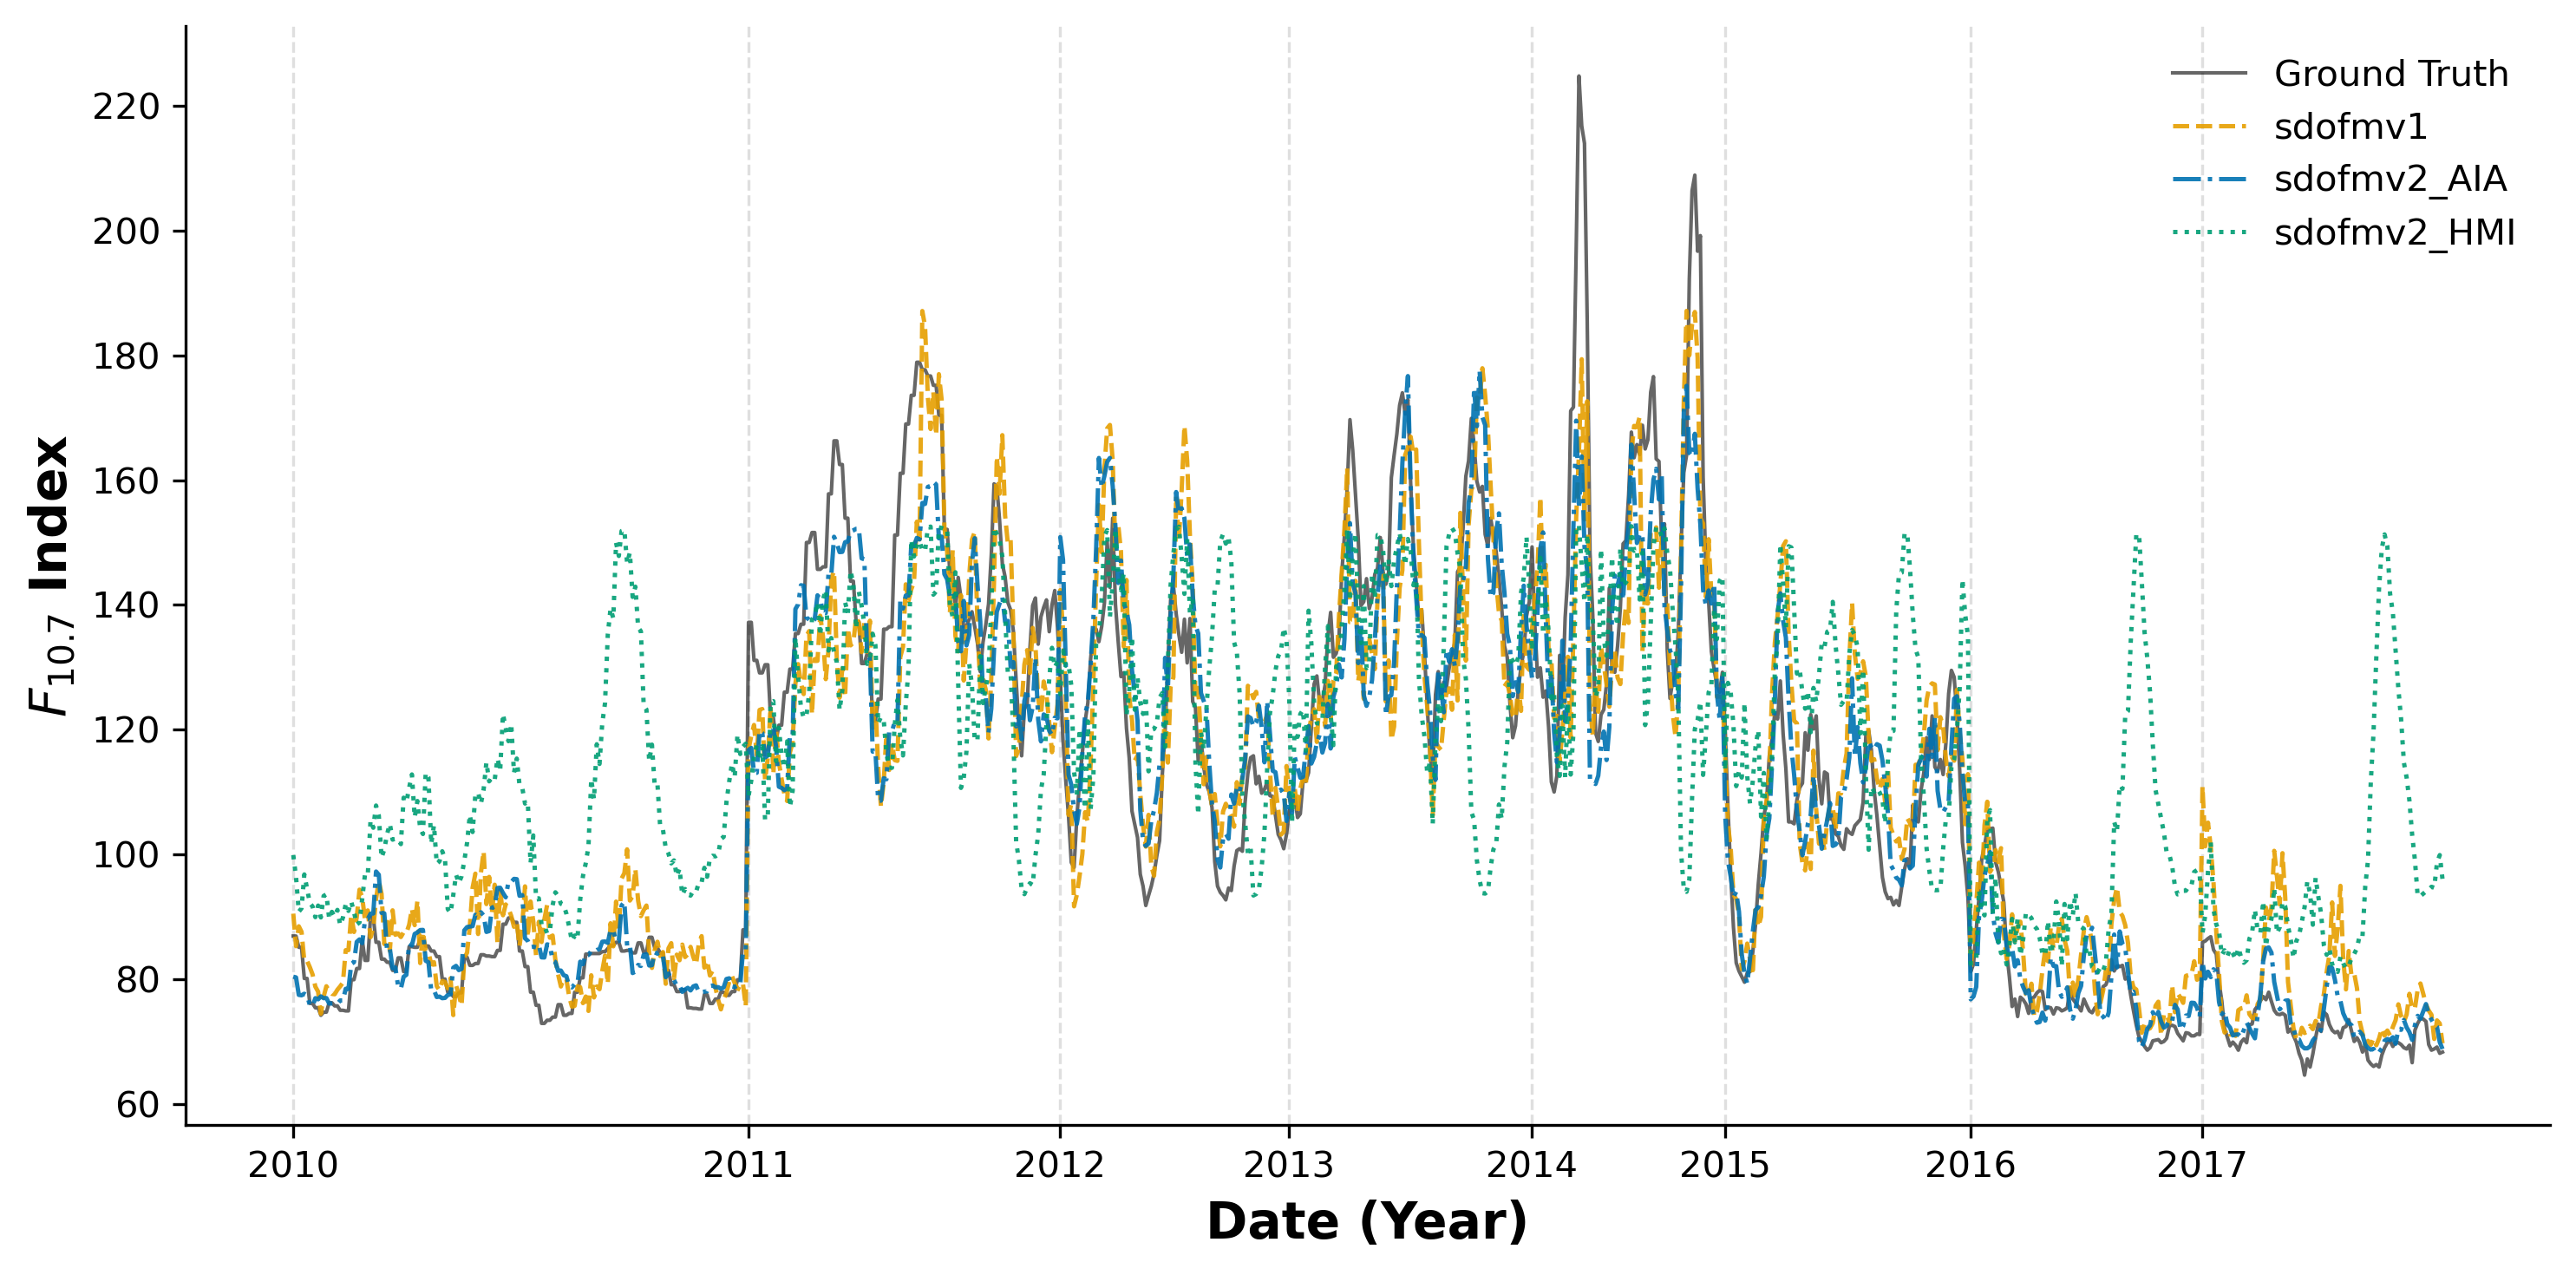

In [16]:
dates = pd.to_datetime(timestamps)
years = dates.year

x_idx = np.arange(len(dates))
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth: Dark grey or Black is better for the "anchor" data
ax.plot(x_idx, y, label="Ground Truth", color='black', linewidth=1, alpha=0.6)

# Model 1: Orange (Okabe-Ito)
ax.plot(x_idx, preds_sdofmv1, label="sdofmv1", color='#E69F00', 
        linewidth=1.2, alpha=0.9, linestyle='--')

# Model 2 (AIA): Darker Blue (Okabe-Ito) - distinct from orange
ax.plot(x_idx, preds_sdofmv2_AIA, label="sdofmv2_AIA", color='#0072B2', 
        linewidth=1.2, alpha=0.9, linestyle='-.')

# Model 2 (HMI): Teal (Okabe-Ito) - much easier to see than lime green
ax.plot(x_idx, preds_sdofmv2_HMI, label="sdofmv2_HMI", color='#009E73', 
        linewidth=1.2, alpha=0.9, linestyle=':')

unique_years, indices = np.unique(years, return_index=True)

ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel("$F_{10.7}$ Index", fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()